# Part 6b: Deterministic continuous-time dynamical systems (ODEs)

As discucsed briefly in the introduction, `dynestyx` also supports inference in deterministic dynamical systems, such as those generated via an ordinary differential equation (ODE). In this tutorial, we show how to use the `ODESimulator` to perform Bayesian inference on the parameters of an ODE.

## The System

In this example, we'll use the Lorenz 63 model. The state is 3-dimensional, $x \in \mathbb{R}^3$, and the evolution will be specified as 

$$ \frac{\mathrm{d}}{\mathrm{d} t} x(t) = \left( \begin{bmatrix} -10 & 10 & 0 \\ \rho - x_2(t) & -1 & 0 \\ x_1(t) & 0 & \frac{-8}{3} \end{bmatrix} \right) x(t)$$

where the transition depends on some parameter $\rho$. 

Let's set up a probabilistic program for this dynamical system by placing a prior on $\rho$ and $x(t=0)$, and a Gaussian likelihood on $y(t_k) \,|\, x(t_k)$:

$$ \rho \sim U(10.0, 40.0), $$

$$ x(t=0) \sim \mathcal{N}(0, 2.0^2 I), $$

$$ y(t_k) \,|\, x_{t_k} \sim \mathcal{N}(0.0, 1.0^2).$$

$$ y(t_k) \mid x(t_k) \sim \mathcal{N}\big(\underbrace{\begin{bmatrix} 1 & 0 & 0 \end{bmatrix}}_{H} x(t_k), \underbrace{1.0^2}_R\big), $$

where $H$ is the linear observation matrix, in this case, selecting our observations as the first component $x_1(t_k)$, and $R$ is the observation covariance, in this case, the scalar $1.0$.

Our end goal will be inference of $x_0 \triangleq x(t=0)$ and $\rho$ given the data, i.e., $p(\rho, x_0 \,|\, y_{1:T})$. In this tutorial, we will obtain that by obtaining the posterior over all states, $p(\rho, x_{0:T} \,|\, y_{1:T})$, and then marginalizing the full posterior to obtain $p(\rho, x_0 \,|\, y_{1:T})$. This is juxtaposed to many of the other tutorials, such as in [the quickstart](../../quickstart/), where we first marginalized the dynamical system via a filter, and then sample from that marginalized model directly.

## Specifying the Model in `dynestyx`

To specify the model in `dynestyx`, we specify a `ContinuousStateEvolution` that does not include a diffusion.

In [1]:
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist

import dynestyx as dsx
from dynestyx import (
    ContinuousTimeStateEvolution,
    DynamicalModel,
    LinearGaussianObservation,
    flatten_draws,
)

state_dim = 3
observation_dim = 1


def continuous_time_deterministic_l63_model(rho=None, obs_times=None, obs_values=None, predict_times=None):
    """Model that samples drift parameter rho and uses it in dynamics (ODE, no diffusion)."""
    rho = numpyro.sample("rho", dist.Uniform(10.0, 40.0), obs=rho)

    # Create the dynamical model with sampled rho
    dynamics = DynamicalModel(
        initial_condition=dist.MultivariateNormal(
            loc=jnp.zeros(state_dim), covariance_matrix=2.0**2 * jnp.eye(state_dim)
        ),
        state_evolution=ContinuousTimeStateEvolution(
            drift=lambda x, u, t: jnp.array(
                [
                    10.0 * (x[1] - x[0]),
                    x[0] * (rho - x[2]) - x[1],
                    x[0] * x[1] - (8.0 / 3.0) * x[2],
                ]
            )
        ),
        observation_model=LinearGaussianObservation(
            H=jnp.eye(observation_dim, state_dim),
            R=jnp.eye(observation_dim),
        ),
    )

    return dsx.sample("f", dynamics, obs_times=obs_times, obs_values=obs_values, predict_times=predict_times)

## Generating Samples From the Generative Model

As in our previous examples, we must specify a `dsx.simulators` object to tell `dynestyx` how to generate samples. For determeinistic, continuous-time dynamical systems, we call an `ODESimulator`. This is primarily a frontend for a conventional numerical solver, housed by `diffrax`, coupled with sampling from the observation model.

In [2]:
import jax.random as jr
from numpyro.infer import Predictive

from dynestyx import ODESimulator

# Generate longer trajectory: training portion + held-out future for rollout evaluation
n_train = 5.0
T_forecast = 2.0
obs_times_full = jnp.arange(0.0, n_train + T_forecast, 0.0025)

# Train / test split
obs_times = obs_times_full[obs_times_full <= n_train]
obs_times_test = obs_times_full[obs_times_full > n_train]

prng_key = jr.PRNGKey(0)
predictive_key = jr.split(prng_key, 2)[1]

predictive_model = Predictive(continuous_time_deterministic_l63_model, num_samples=1)

with ODESimulator():
    synthetic_samples = predictive_model(predictive_key, rho=28.0, predict_times=obs_times_full)

We can visualize the resulting dynamical system and observations:

synthetic shapes: (1, 1, 2800) (1, 1, 2800, 3) (1, 1, 2800, 1)


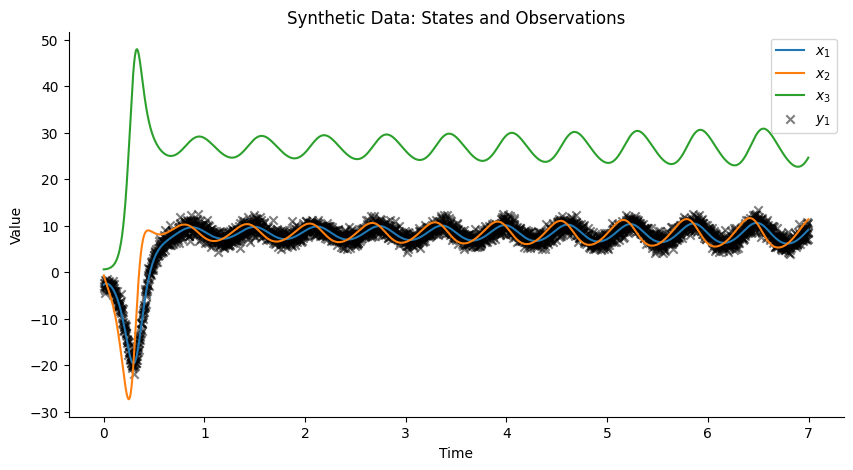

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

print(
    "synthetic shapes:",
    synthetic_samples["f_times"].shape,
    synthetic_samples["f_states"].shape,
    synthetic_samples["f_observations"].shape,
)
# Expected: (num_samples, n_sim, T, ...) with num_samples=n_sim=1 in this cell.
times = synthetic_samples["f_times"][0, 0, :]
states = synthetic_samples["f_states"][0, 0, :, :]
observations = synthetic_samples["f_observations"][0, 0, :, 0]

# Training portion for MCMC; future withheld for rollout eval
mask_train = times <= n_train
times_train = times[mask_train]
observations_train = observations[mask_train]
state_colors = sns.color_palette("tab10", 3)

for d in range(3):
    plt.plot(times, states[:, d], label=fr"$x_{d + 1}$", color=state_colors[d])

plt.scatter(
    times,
    observations,
    label=r"$y_1$",
    marker="x",
    color="black",
    alpha=0.5,
)
plt.title("Synthetic Data: States and Observations")
plt.xlabel("Time")
plt.ylabel("Value")
sns.despine()
plt.legend()
plt.show()

We can also visualize in 3d to see the typical Lorenz attractor shape.

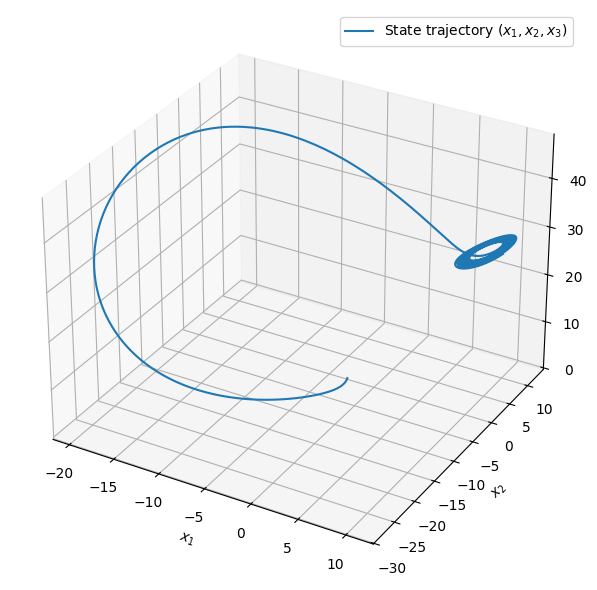

In [4]:
obs = synthetic_samples["f_observations"][0, 0, :, :]
states_3d = synthetic_samples["f_states"][0, 0, :, :]

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

ax.plot(
    states_3d[:, 0],
    states_3d[:, 1],
    states_3d[:, 2],
    label=r"State trajectory $(x_1, x_2, x_3)$",
)

ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_zlabel("$x_3$")
ax.legend()
plt.tight_layout()
plt.show()

## Bayesian Inference via Simulation

For a deterministic dynamical system, one option for inference is to deterministically solve the system -- given the initial state and system parameters -- and solve as a conventional probabilistic program. While this is not the most scalable solution for very long or high-dimensional time series (for those, we can use [probabilistic solvers](https://arxiv.org/abs/2110.11812), to be incorporated into `dynestyx` soon), it is reasonable for time series on the order of hundreds of points with moderate dimension, so long as the underlying ODE is relatively well-behaved.

To perform inference via this "unrolling" in `dynestyx`, we pass the observed values `obs_values` along with `obs_times` to the model:

The resulting model is directly compatible with `numpyro` inference tools, which will perform joint (parameter, state) inference, for example, using NUTS. The resulting inference will be quite slow -- we are running a numerical solver at every time step, that the inference method must backpropagate through -- but relatively accurate.

In [ ]:
import jax.random as jr
from numpyro.infer import MCMC, NUTS

mcmc_key = jr.PRNGKey(42)

with dsx.LatentStateBuilder():
    nuts_kernel = NUTS(continuous_time_deterministic_l63_model)
    mcmc = MCMC(nuts_kernel, num_samples=500, num_warmup=500)
    mcmc.run(mcmc_key, obs_times=times_train, obs_values=observations_train)

posterior_samples = mcmc.get_samples()

The posterior of parameters, such as $\rho$, is thus available:

In [ ]:
import arviz as az

az.style.use("arviz-white")

# For plotting reasons
parameter_posterior_samples = {"rho": posterior_samples["rho"]}

az.plot_posterior(
    parameter_posterior_samples, var_names=["rho"], hdi_prob=0.95, ref_val=28.0
)

plt.show()

As in the discrete-time inference tutorial, we also once again get smoothing estimates of the underlying states.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

times = synthetic_samples["f_times"][0, 0, :]
synthetic_states = synthetic_samples["f_states"][0, 0, :, :]
states_raw = jnp.asarray(posterior_samples["f_states"])
# Unlist draw axes explicitly: (num_draws, T, D)
states = states_raw.reshape((-1, states_raw.shape[-2], states_raw.shape[-1]))
print("posterior f_states shape:", states_raw.shape, "->", states.shape)

# Posterior states are at times_train (training portion only)
median = jnp.median(states, axis=0)  # (T, D)
p10 = jnp.percentile(states, 10, axis=0)  # (T, D)
p90 = jnp.percentile(states, 90, axis=0)  # (T, D)
state_colors = sns.color_palette("tab10", 3)

for d in range(3):
    plt.plot(
        times_train,
        synthetic_states[mask_train, d],
        label=fr"True $x_{d + 1}$",
        color=state_colors[d],
    )
    plt.fill_between(times_train, p10[:, d], p90[:, d], alpha=0.3, color=state_colors[d])
    plt.plot(
        times_train,
        median[:, d],
        label=fr"Posterior median $x_{d + 1}$",
        lw=2,
        ls="--",
        color=state_colors[d],
    )

plt.title("State Trajectories: Ground Truth and Posterior")
plt.xlabel("Time")
plt.ylabel("Value")
sns.despine()
plt.legend(ncol=2)
plt.show()

We can also visualize the posterior distribtuion on initial conditions (i.e., $p(x_0 \,|\, y_{0:T})$) and compare it to the prior $p(x_0) \sim \mathcal{N}(0.0, 2.0^2 I)$.

In [ ]:
import numpy as np

state_colors = sns.color_palette("tab10", 3)

for d in range(3):
    sns.kdeplot(
        posterior_samples["f_x_0"][:, d],
        label=fr"Posterior $x_{d + 1}(t=0)$",
        color=state_colors[d],
    )
    plt.axvline(
        x=synthetic_samples["f_states"][0, 0, 0, d],
        linestyle="--",
        color=state_colors[d],
    )

sns.kdeplot(np.random.randn(10_000), label="Prior $p(x_0)$", color="black")
plt.legend(loc="upper right")
plt.show()

We can even look at joint posteriors $p(\rho, x_0 \,|\, y_{1:T})$. For example, let us look at $p(x_1(t=0))$ and $p(x_1(t=0), x_2(t=0))$:

In [ ]:
x0_raw = jnp.asarray(posterior_samples["f_x_0"])
x0 = flatten_draws(x0_raw)  # (num_samples, n_sim=1, state_dim) → (num_samples, state_dim)
print("posterior f_x_0 shape:", x0_raw.shape, "->", x0.shape)

plt.title(r"Posterior $p(x_1(t=0), x_2(t=0) \,|\, y_{1:T})$")
plt.hexbin(
    x0[:, 0],
    x0[:, 1],
    cmap="inferno",
    gridsize=30,
)
plt.colorbar()
sns.despine()
plt.show()

plt.title(r"Posterior $p(\rho, x_1(t=0) \,|\, y_{1:T})$")
plt.hexbin(
    posterior_samples["rho"],
    x0[:, 0],
    cmap="inferno",
    gridsize=30,
)
plt.colorbar()
plt.show()

We can see that the posterior of the initial conditions is tightly correlated, whilst the posterior of $\rho$ and $x_1(t=0)$ appears nearly independent.

### Rollout: Filter + Simulator with `predict_times`

To evaluate **rollout quality**—especially forecasts into the future—use **Filter + ODESimulator** with `predict_times`. The filter conditions on training observations; the simulator rolls out trajectories at `predict_times` (the held-out future).

**Shape convention:** simulator outputs always include a leading `n_simulations` axis (size 1 by default). Under `Predictive`, there is also a leading `num_samples` axis. In the cells below, we handle those axes explicitly via indexing/reshaping and flatten draw axes with `reshape` when building intervals.

In [ ]:
from numpyro.infer import Predictive

from dynestyx import Filter
from dynestyx.inference.filter_configs import ContinuousTimeEKFConfig

# Build train/test split from synthetic timeline.
times_full = synthetic_samples["f_times"][0, 0, :]
times_train_arr = jnp.asarray(times_train)

n_train_pts = times_train_arr.shape[0]
times_test = times_full[n_train_pts:]

predictive = Predictive(
    continuous_time_deterministic_l63_model,
    posterior_samples=posterior_samples,
    exclude_deterministic=False,
)
with ODESimulator(n_simulations=10):
    with Filter(
        filter_config=ContinuousTimeEKFConfig(
            record_filtered_states_mean=True, record_filtered_states_cov_diag=True
        )
    ):
        samples = predictive(
            jr.PRNGKey(99),
            obs_times=times_train_arr,
            obs_values=observations_train,
            predict_times=times_test,
        )


In [ ]:

# samples["f_predicted_states"].shape is (500, 1, 799, 3)
pred_states = jnp.asarray(samples["f_predicted_states"])  # (num_samples, n_sim, T_pred, D)
pred_times_arr = jnp.asarray(samples["f_predicted_times"])  # (num_samples, n_sim, T_pred)
filtered_means = jnp.asarray(samples["f_filtered_states_mean"])  # (num_samples, T_train, D)
filtered_std = jnp.sqrt(jnp.asarray(samples["f_filtered_states_cov_diag"]))  # (num_samples, T_train, D)

# flatten_draws merges (num_samples, n_sim, T, D) → (num_samples*n_sim, T, D).
# Filter outputs (f_filtered_states_mean, f_filtered_states_cov_diag) are (num_samples, T, D) — no n_sim.
pred_draws = flatten_draws(pred_states)
pred_t = flatten_draws(pred_times_arr)[0]

fmean_draws = filtered_means   # (num_samples, T_train, D)
fstd_draws = filtered_std      # (num_samples, T_train, D)

pred_lo = jnp.percentile(pred_draws, 2.5, axis=0)
pred_hi = jnp.percentile(pred_draws, 97.5, axis=0)
pred_med = jnp.percentile(pred_draws, 50.0, axis=0)

filt_lo = jnp.percentile(fmean_draws - 2.0 * fstd_draws, 2.5, axis=0)
filt_hi = jnp.percentile(fmean_draws + 2.0 * fstd_draws, 97.5, axis=0)
filt_med = jnp.percentile(fmean_draws, 50.0, axis=0)


true_states_full = flatten_draws(jnp.asarray(synthetic_samples["f_states"]))[0]
true_train = true_states_full[:n_train_pts]
true_test = true_states_full[n_train_pts : n_train_pts + pred_t.shape[0]]

# Plot: true states, filtered CI, and rollout CI from posterior+simulator draws
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
state_labels = [r"$x_1$", r"$x_2$", r"$x_3$"]
for i, ax in enumerate(axes):
    ax.fill_between(pred_t, pred_lo[:, i], pred_hi[:, i], alpha=0.30, color="C0", label="Rollout 95% CI")
    ax.plot(pred_t, pred_med[:, i], "b-", lw=1.5, label="Rollout median")

    ax.fill_between(
        times_train_arr,
        filt_lo[:, i],
        filt_hi[:, i],
        alpha=0.25,
        color="green",
        label="Filtered band",
    )
    ax.plot(times_train_arr, filt_med[:, i], "g.-", markersize=4, label="Filtered median")

    ax.plot(times_train_arr, true_train[:, i], "k--", label="True (train)", lw=1)
    ax.plot(pred_t, true_test[:, i], "k:", lw=1.5, label="True (future, held-out)")

    if i == 0:
        ax.scatter(times_train_arr, observations_train, color="C3", marker="x", s=20, label="Observed")

    ax.set_ylabel(state_labels[i])
    ax.legend(loc="upper right", fontsize=8)
    ax.axvline(times_train_arr[-1], color="gray", linestyle=":", alpha=0.7)

axes[0].set_title("Filter + ODESimulator: posterior+simulator CI rollout")
axes[-1].set_xlabel("time")
plt.tight_layout()
plt.show()

**Next:** [Part 7 — HMMs and multiple trajectories](../07_hmm/)